In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Load airport summary from Day 2
airport_df = pd.read_csv('../data/processed/airport_month_summary_day2.csv')

print("Shape:", airport_df.shape)
print("\nColumns:", airport_df.columns.tolist())
print("\nSample:")
print(airport_df.head())

Shape: (396, 9)

Columns: ['ORIGIN', 'MONTH', 'total_flights', 'avg_arr_delay', 'avg_weather_delay', 'weather_delay_flights', 'cancelled_flights', 'weather_delay_rate', 'cancel_rate']

Sample:
  ORIGIN  MONTH  total_flights  avg_arr_delay  avg_weather_delay  \
0    ATL      1            585      15.885510           2.992844   
1    ATL      2            543       6.238274           0.151970   
2    ATL      3            627      12.374384           0.970443   
3    ATL      4            614      18.720067           1.671164   
4    ATL      5            654      22.370607           1.630990   

   weather_delay_flights  cancelled_flights  weather_delay_rate  cancel_rate  
0                     15                 26            0.025641     0.044444  
1                      7                 10            0.012891     0.018416  
2                     11                 18            0.017544     0.028708  
3                     13                 21            0.021173     0.034202  
4  

In [4]:
print("Missing values:")
print(airport_df.isnull().sum())

# Fill any leftover NaN with 0
airport_df = airport_df.fillna(0)
print("\nAfter fill - Missing values:", airport_df.isnull().sum().sum())

Missing values:
ORIGIN                   0
MONTH                    0
total_flights            0
avg_arr_delay            0
avg_weather_delay        0
weather_delay_flights    0
cancelled_flights        0
weather_delay_rate       0
cancel_rate              0
dtype: int64

After fill - Missing values: 0


In [5]:
# Only add these if they're NOT already in the file
# If your Day 2 summary already has them, skip this step

# Likelihood × Severity combined signal
if 'weather_risk_component' not in airport_df.columns:
    airport_df['weather_risk_component'] = (
        airport_df['weather_delay_rate'] * airport_df['avg_weather_delay']
    )

# Check if severe_weather_rate and cascade_rate exist
print(airport_df.columns.tolist())

['ORIGIN', 'MONTH', 'total_flights', 'avg_arr_delay', 'avg_weather_delay', 'weather_delay_flights', 'cancelled_flights', 'weather_delay_rate', 'cancel_rate', 'weather_risk_component']


In [6]:
# Columns available from your current Day 2 file
features = [
    'weather_risk_component',   # new column above
    'cancel_rate',
    'avg_weather_delay',
    'avg_arr_delay'
]

In [7]:
# Define features to normalize
features = ['weather_risk_component', 'cancel_rate', 'avg_weather_delay', 'avg_arr_delay']

# Make sure no negatives (clamp to 0)
for col in features:
    airport_df[col] = airport_df[col].clip(lower=0)

# Apply MinMaxScaler — squishes everything to 0–1 range
scaler = MinMaxScaler()
airport_scaled = airport_df.copy()
airport_scaled[features] = scaler.fit_transform(airport_df[features])

print("After normalization — all values should be between 0 and 1:")
print(airport_scaled[features].describe().round(3))

After normalization — all values should be between 0 and 1:
       weather_risk_component  cancel_rate  avg_weather_delay  avg_arr_delay
count                 396.000      396.000            396.000        396.000
mean                    0.064        0.298              0.144          0.304
std                     0.129        0.185              0.158          0.202
min                     0.000        0.000              0.000          0.000
25%                     0.004        0.154              0.036          0.151
50%                     0.018        0.261              0.092          0.273
75%                     0.060        0.382              0.183          0.457
max                     1.000        1.000              1.000          1.000


In [9]:
airport_scaled['risk_score'] = (
    0.35 * airport_scaled['weather_risk_component'] +
    0.30 * airport_scaled['cancel_rate']            +
    0.20 * airport_scaled['avg_weather_delay']      +
    0.15 * airport_scaled['avg_arr_delay']
)

# Normalize the final score itself to 0–1 as well
airport_scaled['risk_score'] = (
    airport_scaled['risk_score'] - airport_scaled['risk_score'].min()
) / (
    airport_scaled['risk_score'].max() - airport_scaled['risk_score'].min()
)

print("Risk score range:", round(airport_scaled['risk_score'].min(), 3),
      "to", round(airport_scaled['risk_score'].max(), 3))

Risk score range: 0.0 to 1.0


In [10]:
airport_scaled['SEASON'] = airport_scaled['MONTH'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Fall',    10:'Fall',   11:'Fall'
})

In [11]:
def risk_label(score):
    if score >= 0.75:
        return 'Critical'
    elif score >= 0.50:
        return 'High'
    elif score >= 0.25:
        return 'Medium'
    else:
        return 'Low'

airport_scaled['risk_category'] = airport_scaled['risk_score'].apply(risk_label)

print(airport_scaled['risk_category'].value_counts())

risk_category
Low         296
Medium       83
High         13
Critical      4
Name: count, dtype: int64


In [12]:
top_risky = (
    airport_scaled[['ORIGIN', 'MONTH', 'SEASON', 'risk_score', 'risk_category']]
    .sort_values('risk_score', ascending=False)
    .head(20)
)

print("\n=== TOP 20 RISKIEST AIRPORT-MONTHS ===")
print(top_risky.to_string(index=False))


=== TOP 20 RISKIEST AIRPORT-MONTHS ===
ORIGIN  MONTH SEASON  risk_score risk_category
   IAH      5 Spring    1.000000      Critical
   AUS      5 Spring    0.800155      Critical
   TUL      5 Spring    0.775754      Critical
   MSY      5 Spring    0.772887      Critical
   MCO      8 Summer    0.730887          High
   MCO      5 Spring    0.630371          High
   BNA      1 Winter    0.615660          High
   SAT      5 Spring    0.609238          High
   MCO      6 Summer    0.562084          High
   LGA      7 Summer    0.553218          High
   MCO      7 Summer    0.547460          High
   MEM      5 Spring    0.544170          High
   IAH      1 Winter    0.543654          High
   IAH      4 Spring    0.542435          High
   OKC      5 Spring    0.531893          High
   MEM      4 Spring    0.519542          High
   FLL      5 Spring    0.513148          High
   FLL      6 Summer    0.487890        Medium
   MIA      8 Summer    0.487061        Medium
   MSY      4 Spring

In [13]:
annual_risk = (
    airport_scaled.groupby('ORIGIN')['risk_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
annual_risk.columns = ['ORIGIN', 'avg_annual_risk']
print("\n=== ANNUAL AVERAGE RISK RANKING ===")
print(annual_risk.to_string(index=False))


=== ANNUAL AVERAGE RISK RANKING ===
ORIGIN  avg_annual_risk
   IAH         0.338159
   MCO         0.326632
   MSY         0.286007
   FLL         0.271045
   TUL         0.264614
   TPA         0.247127
   SAT         0.245849
   AUS         0.242698
   OKC         0.233664
   MEM         0.229421
   BNA         0.222630
   MIA         0.212686
   LGA         0.208429
   SAN         0.201872
   DEN         0.200394
   ELP         0.184285
   ATL         0.176792
   ORD         0.160525
   DCA         0.154619
   PDX         0.151341
   SLC         0.149105
   MSP         0.148980
   CLT         0.147524
   LAS         0.141687
   RDU         0.141492
   SFO         0.140171
   PHL         0.136163
   DTW         0.126451
   JFK         0.124583
   SEA         0.121702
   LAX         0.108151
   BOS         0.102998
   PHX         0.097486


In [14]:
airport_scaled.to_csv('../data/processed/airport_risk_scores.csv', index=False)
print("✅ Airport risk scores saved!")
print("Shape:", airport_scaled.shape)

✅ Airport risk scores saved!
Shape: (396, 13)


FileNotFoundError: [Errno 2] No such file or directory: '../report/airport_risk_heatmap.png'

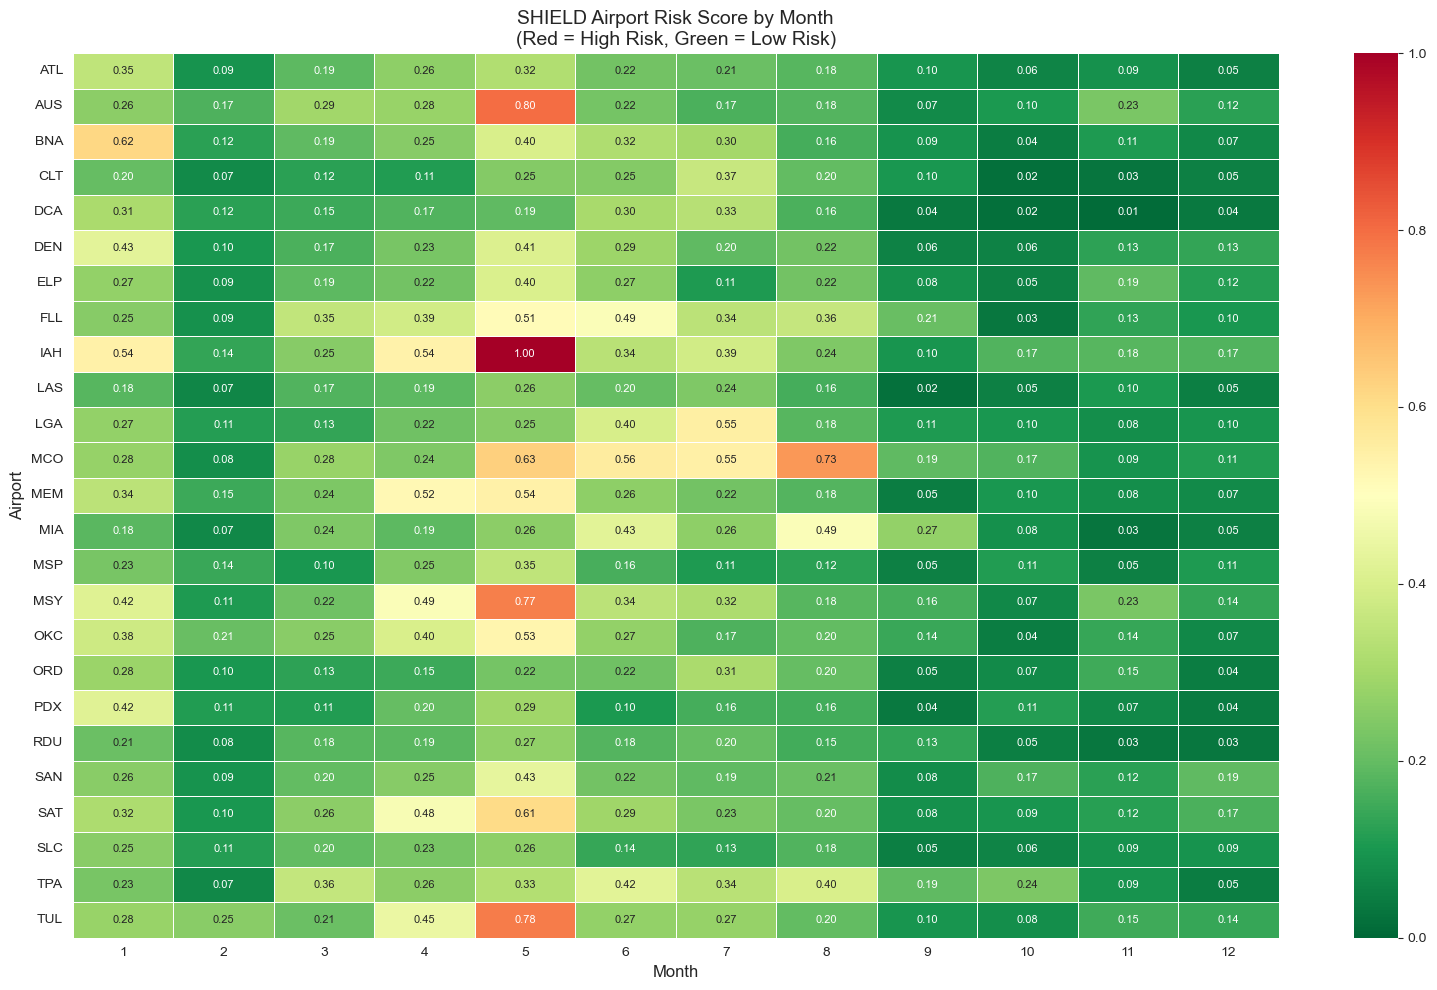

In [15]:
pivot = airport_scaled.pivot_table(
    index='ORIGIN', columns='MONTH', values='risk_score'
)

# Keep only top 25 by average annual risk
top25 = annual_risk.head(25)['ORIGIN'].tolist()
pivot = pivot.loc[pivot.index.isin(top25)]

plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8},
    vmin=0,
    vmax=1
)
plt.title('SHIELD Airport Risk Score by Month\n(Red = High Risk, Green = Low Risk)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Airport', fontsize=12)
plt.tight_layout()
plt.savefig('../report/airport_risk_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

FileNotFoundError: [Errno 2] No such file or directory: '../report/top15_risky_airports.png'

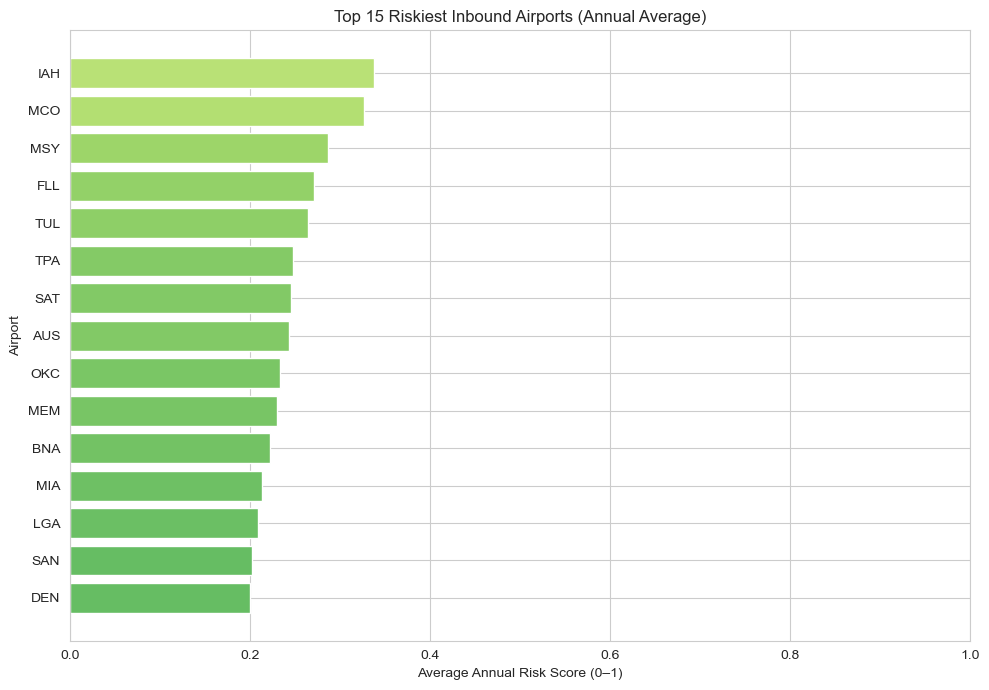

In [16]:
top15 = annual_risk.head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(top15['ORIGIN'], top15['avg_annual_risk'],
                color=plt.cm.RdYlGn_r(top15['avg_annual_risk']))
plt.xlabel('Average Annual Risk Score (0–1)')
plt.ylabel('Airport')
plt.title('Top 15 Riskiest Inbound Airports (Annual Average)')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/top15_risky_airports.png', dpi=200)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../report/seasonal_risk_by_airport.png'

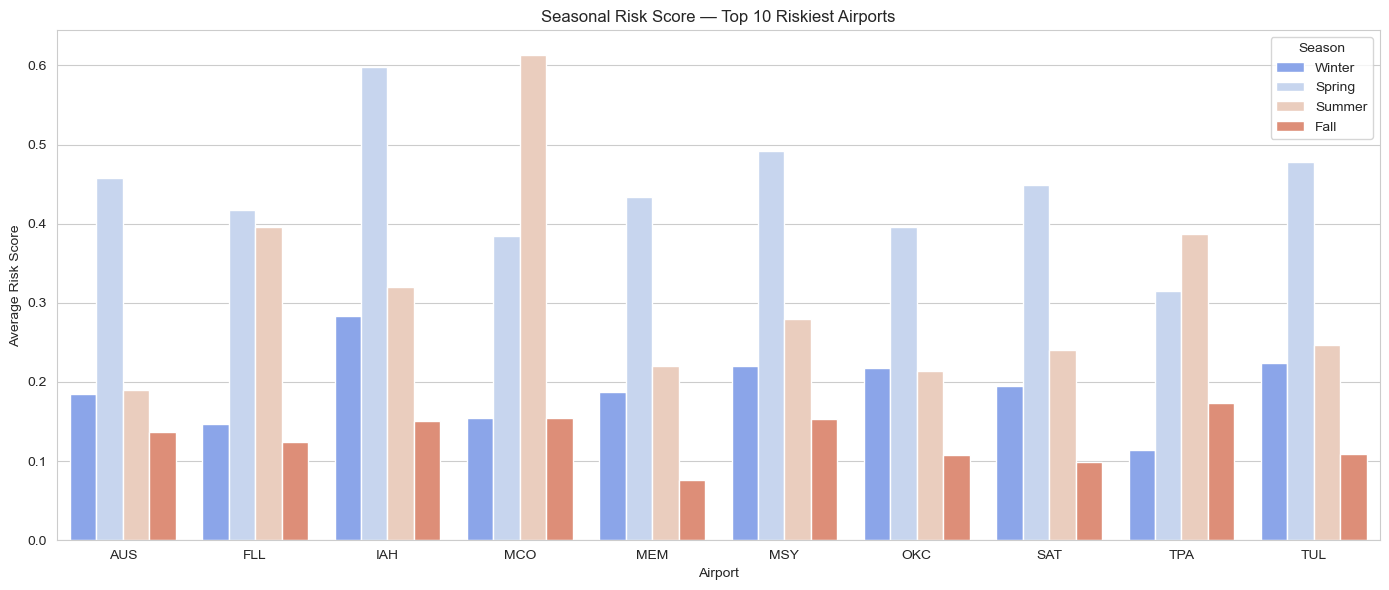

In [17]:
season_risk = airport_scaled.groupby(['ORIGIN', 'SEASON'])['risk_score'].mean().reset_index()
top10 = annual_risk.head(10)['ORIGIN'].tolist()
season_risk_top = season_risk[season_risk['ORIGIN'].isin(top10)]

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
plt.figure(figsize=(14, 6))
sns.barplot(
    data=season_risk_top,
    x='ORIGIN', y='risk_score', hue='SEASON',
    hue_order=season_order, palette='coolwarm'
)
plt.title('Seasonal Risk Score — Top 10 Riskiest Airports')
plt.xlabel('Airport')
plt.ylabel('Average Risk Score')
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('../report/seasonal_risk_by_airport.png', dpi=200)
plt.show()

In [18]:
# This exact file feeds into Day 4 Pair Scoring
day3_output = airport_scaled[['ORIGIN', 'MONTH', 'SEASON', 'risk_score', 'risk_category']]
day3_output.to_csv('../data/processed/airport_risk_day3_final.csv', index=False)
print("✅ Day 3 final output saved — ready for Day 4 Pair Scoring!")
print(day3_output.sample(10))

✅ Day 3 final output saved — ready for Day 4 Pair Scoring!
    ORIGIN  MONTH  SEASON  risk_score risk_category
42     BOS      7  Summer    0.220689           Low
141    JFK     10    Fall    0.000000           Low
123    IAH      4  Spring    0.542435          High
134    JFK      3  Spring    0.083439           Low
175    LGA      8  Summer    0.181998           Low
328    SAT      5  Spring    0.609238          High
260    ORD      9    Fall    0.052552           Low
116    FLL      9    Fall    0.206638           Low
186    MCO      7  Summer    0.547460          High
262    ORD     11    Fall    0.149294           Low
